In [8]:
import os

# Langsung set ke root project pakai path absolut
os.chdir(r'C:\Users\LENOVO\restaurant-revenue-prediction-system')

# Verifikasi
print("Working directory:", os.getcwd())
print("File ada?", os.path.exists('data/raw/restaurant_data.csv'))

Working directory: C:\Users\LENOVO\restaurant-revenue-prediction-system
File ada? True


In [11]:
import os
import sys
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set root project
os.chdir(r'C:\Users\LENOVO\restaurant-revenue-prediction-system')
sys.path.append(r'C:\Users\LENOVO\restaurant-revenue-prediction-system')

# Load data
from scripts.preprocess_data import load_and_preprocess
X_train, X_test, y_train, y_test, scaler, feature_names = load_and_preprocess()

Dataset loaded: 8368 baris × 17 kolom

Tipe data kolom:
Name                       object
Location                   object
Cuisine                    object
Rating                    float64
Seating Capacity            int64
Average Meal Price        float64
Marketing Budget            int64
Social Media Followers      int64
Chef Experience Years       int64
Number of Reviews           int64
Avg Review Length          object
Ambience Score            float64
Service Quality Score     float64
Parking Availability       object
Weekend Reservations        int64
Weekday Reservations        int64
Revenue                   float64
dtype: object
  Avg Review Length null setelah convert: 8368
  Semua null → diisi 0
  Avg Review Length setelah fix: int64
  Sample nilai: [0, 0, 0]

Statistik Revenue:
  Min    : 184,708.52
  Max    : 1,531,867.55
  Mean   : 656,070.56
  Median : 604,242.08
  Null   : 0

Baris setelah drop null: 8368 (dihapus 0)
  Encoded 'Location': ['Downtown', 'Rural', 'Suburb

In [12]:
# Training 3 baseline model
mlflow.set_experiment("restaurant_revenue_prediction")

models = {
    "Ridge_Regression": Ridge(alpha=1.0),
    "Random_Forest_Regressor": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "Gradient_Boosting_Regressor": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "MAE" : round(mean_absolute_error(y_test, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        "R2"  : round(r2_score(y_test, y_pred), 4)
    }

# Tampilkan tabel hasil
results_df = pd.DataFrame(results).T.sort_values('MAE')
print(results_df)

                                  MAE      RMSE      R2
Gradient_Boosting_Regressor   5865.12   7383.78  0.9992
Random_Forest_Regressor       6126.93   7854.79  0.9991
Ridge_Regression             43104.09  56390.60  0.9556


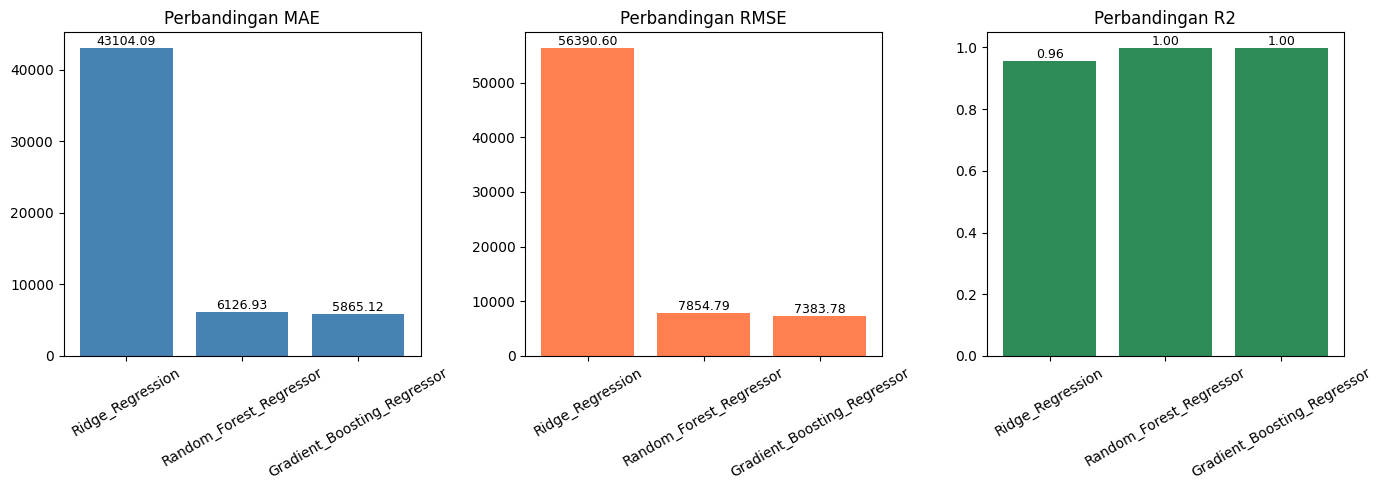

In [13]:
# Plot perbandingan MAE
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors  = ['steelblue', 'coral', 'seagreen']

for i, metric in enumerate(metrics):
    values = [results[m][metric] for m in results]
    axes[i].bar(results.keys(), values, color=colors[i])
    axes[i].set_title(f'Perbandingan {metric}')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(values):
        axes[i].text(j, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('reports/figures/perbandingan_baseline.png', dpi=150)
plt.show()